# D1 — Come si finanziano i grandi comuni italiani?

Notebook di supporto alla Discussion D1 su SIOPE comuni.

**Perimetro**
- anni: 2023, 2024
- livello: 10 grandi comuni
- base dati: output `cross_year` del progetto costruito dal `mart` labeled
- filtro metodologico: `is_titolo_9 = false`
- confronto principale: composizione per titolo e confronto diretto su alcune voci chiave

**Note chiave**
- Il dataset del progetto include anche il 2025, ma questo notebook resta volutamente focalizzato su `2023-2024` per restare allineato alla Discussion D1.
- Roma Capitale va letta con cautela: alcune componenti di trasferimento e funzione istituzionale non sono perfettamente comparabili agli altri comuni.
- I totali nazionali citati nella Discussion D1 non sono prodotti da questo notebook: qui il focus e' ristretto ai 10 grandi comuni.


In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


pd.options.display.float_format = '{:,.2f}'.format


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'entrate').exists() and (candidate / 'anagrafica').exists():
            return candidate
    raise RuntimeError('Repo root non trovato')


REPO_ROOT = find_repo_root(Path.cwd())
CROSS_PATH = REPO_ROOT / 'out' / 'data' / 'cross' / 'siope_comparto_2y' / 'siope_entrate_comuni_agg_labeled_multi_anno.parquet'
ANAG_ENTI_PATH = REPO_ROOT / 'out' / 'data' / 'clean' / 'siope_anag_enti_seed' / '2024' / 'siope_anag_enti_seed_2024_clean.parquet'
# Base popolazione fissa 2024: usata come riferimento per 2023-2024.

YEARS = [2023, 2024]

COMUNI = [
    ('ROMA CAPITALE', 'Roma'),
    ('COMUNE DI MILANO', 'Milano'),
    ('COMUNE DI NAPOLI', 'Napoli'),
    ('COMUNE DI TORINO', 'Torino'),
    ('COMUNE DI GENOVA', 'Genova'),
    ('COMUNE DI PALERMO', 'Palermo'),
    ('COMUNE DI BOLOGNA', 'Bologna'),
    ('COMUNE DI FIRENZE', 'Firenze'),
    ('COMUNE DI BARI', 'Bari'),
    ('COMUNE DI CATANIA', 'Catania'),
]

COMUNI_CANONICI = [row[0] for row in COMUNI]
COMUNI_LABELS = dict(COMUNI)

VOCI_CHIAVE = {
    'IMU': ['1.01.01.06.001', '1.01.01.06.002'],
    'Addizionale comunale IRPEF': ['1.01.01.16.001', '1.01.01.16.002'],
    'Entrate rifiuti': ['1.01.01.51.001', '1.01.01.51.002', '1.01.01.61.001', '1.01.01.61.002'],
    'Fondi perequativi': ['1.03.01.01.001'],
    'Trasferimenti correnti principali': ['2.01.01.01.001', '2.01.01.02.001'],
    'Contributi agli investimenti principali': ['4.02.01.01.001', '4.02.01.02.001'],
}

TITOLI = {
    '0': 'Titolo 0 / non classificato',
    '1': 'Tributarie',
    '2': 'Trasferimenti correnti',
    '3': 'Extratributarie',
    '4': 'Conto capitale',
    '5': 'Riduzione attività fin.',
    '6': 'Accensione prestiti',
    '7': 'Anticipazioni',
}

TITOLI_ORDER = list(TITOLI.values())
TITOLI_COLORS = ['#546E7A', '#1565C0', '#2E7D32', '#EF6C00', '#6A1B9A', '#C62828', '#4E342E', '#757575']

con = duckdb.connect()


## 1. Copertura 2023-2024

Verifichiamo che i due anni usati per D1 siano completi sui grandi comuni selezionati.


In [2]:
copertura = con.execute(
    """
    select
        anno,
        min(periodo_min) as primo_periodo,
        max(periodo_max) as ultimo_periodo,
        count(distinct denominazione_ente) as comuni_presenti
    from read_parquet($cross_path)
    where is_titolo_9 = false
          and anno in $years
      and denominazione_ente in $comuni
    group by 1
    order by 1
    """,
    {'cross_path': str(CROSS_PATH), 'comuni': COMUNI_CANONICI, 'years': YEARS},
).fetchdf()

copertura


,anno,primo_periodo,ultimo_periodo,comuni_presenti
0,2023,01,12,10
1,2024,01,12,10


## 2. Popolazione da anagrafica SIOPE

Uso `codice_col8` dall'anagrafica SIOPE come popolazione residente **solo per `tipo_ente = COMUNE`**.

**Nota metodologica**
- la base popolazione è fissa sull'anagrafica `2024`; non è una popolazione annuale aggiornata
- questo è sufficiente per un confronto pro-capite esplorativo su D1 tra `2023` e `2024`


In [3]:
popolazione = con.execute(
    """
    select
        denominazione_ente,
        cast(codice_col8 as bigint) as popolazione_residente
    from read_parquet($anag_enti_path)
    where tipo_ente = 'COMUNE'
      and denominazione_ente in $comuni
    order by denominazione_ente
    """,
    {'anag_enti_path': str(ANAG_ENTI_PATH), 'comuni': COMUNI_CANONICI},
).fetchdf()

if len(popolazione) != len(COMUNI_CANONICI):
    missing = sorted(set(COMUNI_CANONICI) - set(popolazione['denominazione_ente']))
    raise ValueError(f'Comuni mancanti nell anagrafica SIOPE: {missing}')

if popolazione['popolazione_residente'].isna().any() or (popolazione['popolazione_residente'] <= 0).any():
    raise ValueError('codice_col8 contiene valori null o non validi per almeno un comune selezionato')

popolazione['citta'] = popolazione['denominazione_ente'].map(COMUNI_LABELS)
popolazione


,denominazione_ente,popolazione_residente,citta
0,COMUNE DI BARI,316226,Bari
1,COMUNE DI BOLOGNA,390098,Bologna
2,COMUNE DI CATANIA,298680,Catania
3,COMUNE DI FIRENZE,362613,Firenze
4,COMUNE DI GENOVA,562422,Genova
5,COMUNE DI MILANO,1371499,Milano
6,COMUNE DI NAPOLI,913704,Napoli
7,COMUNE DI PALERMO,630427,Palermo
8,COMUNE DI TORINO,851199,Torino
9,ROMA CAPITALE,2751747,Roma


## 3. Totali per anno: valori assoluti, miliardi e pro-capite

Il confronto assoluto da solo favorisce i comuni più grandi. Per questo aggiungiamo anche una normalizzazione minima per abitante.


In [4]:
totali = con.execute(
    """
    with base as (
        select anno, denominazione_ente, importo_totale_eur
        from read_parquet($cross_path)
        where is_titolo_9 = false
          and anno in $years
          and denominazione_ente in $comuni
    ), anag as (
        select
            denominazione_ente,
            cast(codice_col8 as bigint) as popolazione_residente
        from read_parquet($anag_enti_path)
        where tipo_ente = 'COMUNE'
          and denominazione_ente in $comuni
    )
    select
        b.anno,
        b.denominazione_ente,
        a.popolazione_residente,
        round(sum(b.importo_totale_eur), 2) as entrate_totali_eur,
        round(sum(b.importo_totale_eur) / 1e9, 3) as entrate_totali_mld,
        round(sum(b.importo_totale_eur) / a.popolazione_residente, 2) as entrate_per_abitante_eur
    from base b
    join anag a using (denominazione_ente)
    group by 1, 2, 3
    order by anno, entrate_totali_eur desc
    """,
    {'cross_path': str(CROSS_PATH), 'comuni': COMUNI_CANONICI, 'anag_enti_path': str(ANAG_ENTI_PATH), 'years': YEARS},
).fetchdf()

totali['citta'] = totali['denominazione_ente'].map(COMUNI_LABELS)
totali = totali[['anno', 'citta', 'denominazione_ente', 'popolazione_residente', 'entrate_totali_eur', 'entrate_totali_mld', 'entrate_per_abitante_eur']]
totali


,anno,citta,denominazione_ente,popolazione_residente,entrate_totali_eur,entrate_totali_mld,entrate_per_abitante_eur
0,2023,Roma,ROMA CAPITALE,2751747,"5,566,885,808.40",5.57,"2,023.04"
1,2023,Milano,COMUNE DI MILANO,1371499,"3,793,719,953.70",3.79,"2,766.11"
2,2023,Napoli,COMUNE DI NAPOLI,913704,"1,998,537,883.76",2.00,"2,187.29"
3,2023,Torino,COMUNE DI TORINO,851199,"1,744,902,350.32",1.75,"2,049.93"
4,2023,Palermo,COMUNE DI PALERMO,630427,"1,284,474,100.60",1.28,"2,037.47"
5,2023,Genova,COMUNE DI GENOVA,562422,"1,137,745,982.84",1.14,"2,022.94"
6,2023,Firenze,COMUNE DI FIRENZE,362613,"817,390,549.55",0.82,"2,254.17"
7,2023,Bologna,COMUNE DI BOLOGNA,390098,"756,114,877.62",0.76,"1,938.27"
8,2023,Catania,COMUNE DI CATANIA,298680,"455,439,056.60",0.46,"1,524.84"
9,2023,Bari,COMUNE DI BARI,316226,"434,898,457.53",0.43,"1,375.28"


## 4. Composizione per titolo SIOPE

Per D1 la classificazione più solida è quella per titolo, ricavata dal primo carattere di `codice_voce`.


In [5]:
composizione = con.execute(
    """
    with base as (
        select
            anno,
            denominazione_ente,
            left(codice_voce, 1) as titolo,
            importo_totale_eur
        from read_parquet($cross_path)
        where is_titolo_9 = false
          and anno in $years
          and denominazione_ente in $comuni
    )
    select
        anno,
        denominazione_ente,
        titolo,
        round(sum(importo_totale_eur), 2) as importo_totale_eur,
        round(sum(importo_totale_eur) / 1e9, 3) as importo_totale_mld,
        round(
            sum(importo_totale_eur)
            / sum(sum(importo_totale_eur)) over (partition by anno, denominazione_ente),
            4
        ) as quota
    from base
    group by 1, 2, 3
    order by anno, denominazione_ente, importo_totale_eur desc
    """,
    {'cross_path': str(CROSS_PATH), 'comuni': COMUNI_CANONICI, 'years': YEARS},
).fetchdf()

composizione['citta'] = composizione['denominazione_ente'].map(COMUNI_LABELS)
composizione['titolo_label'] = composizione['titolo'].map(TITOLI).fillna('Altro')
composizione


,anno,denominazione_ente,titolo,importo_totale_eur,importo_totale_mld,quota,citta,titolo_label
0,2023,COMUNE DI BARI,1,"233,624,451.89",0.23,0.54,Bari,Tributarie
1,2023,COMUNE DI BARI,2,"86,870,824.10",0.09,0.20,Bari,Trasferimenti correnti
2,2023,COMUNE DI BARI,4,"67,592,100.60",0.07,0.16,Bari,Conto capitale
3,2023,COMUNE DI BARI,3,"46,202,621.54",0.05,0.11,Bari,Extratributarie
4,2023,COMUNE DI BARI,5,"608,459.40",0.00,0.00,Bari,Riduzione attività fin.
...,...,...,...,...,...,...,...,...
131,2024,ROMA CAPITALE,3,"920,375,469.39",0.92,0.15,Roma,Extratributarie
132,2024,ROMA CAPITALE,4,"425,648,413.35",0.43,0.07,Roma,Conto capitale
133,2024,ROMA CAPITALE,6,"314,209,271.84",0.31,0.05,Roma,Accensione prestiti
134,2024,ROMA CAPITALE,5,"114,428,788.83",0.11,0.02,Roma,Riduzione attività fin.


### Check su titolo 0

Il titolo `0` non è una classe standard SIOPE da leggere come macro-categoria autonoma. Lo tengo visibile per non nasconderlo dentro `Altro`, in particolare per Roma Capitale.


In [6]:
titolo_zero = composizione[composizione['titolo'] == '0'].copy()
titolo_zero[['anno', 'citta', 'importo_totale_eur', 'importo_totale_mld', 'quota']]


,anno,citta,importo_totale_eur,importo_totale_mld,quota
5,2023,Bari,0.00,0.00,0.00
12,2023,Bologna,0.00,0.00,0.00
17,2023,Catania,0.00,0.00,0.00
24,2023,Firenze,0.00,0.00,0.00
31,2023,Genova,0.00,0.00,0.00
38,2023,Milano,0.00,0.00,0.00
45,2023,Napoli,0.00,0.00,0.00
53,2023,Palermo,0.00,0.00,0.00
60,2023,Torino,0.00,0.00,0.00
67,2023,Roma,"8,753,710.78",0.01,0.00


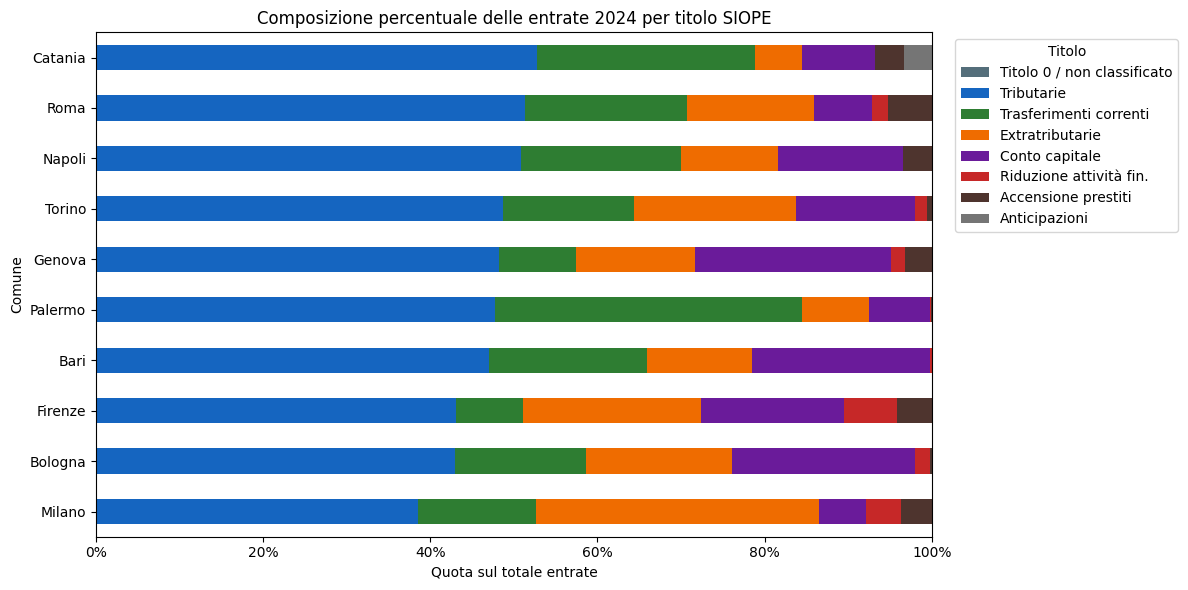

In [7]:
pivot_2024 = (
    composizione[composizione['anno'] == 2024]
    .pivot_table(index='citta', columns='titolo_label', values='quota', fill_value=0)
)
cols_present = [c for c in TITOLI_ORDER if c in pivot_2024.columns]
pivot_2024 = pivot_2024[cols_present].sort_values('Tributarie', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_2024.plot(kind='barh', stacked=True, ax=ax, color=TITOLI_COLORS[: len(cols_present)])
ax.set_title('Composizione percentuale delle entrate 2024 per titolo SIOPE')
ax.set_xlabel('Quota sul totale entrate')
ax.set_ylabel('Comune')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(title='Titolo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Voci chiave della Discussion

Qui restringo il focus alle voci citate esplicitamente in D1: IMU, addizionale IRPEF, entrate rifiuti, fondi perequativi, trasferimenti correnti principali e contributi agli investimenti principali.


In [8]:
voci_chiave = con.execute(
    """
    with base as (
        select anno, denominazione_ente, codice_voce, importo_totale_eur
        from read_parquet($cross_path)
        where is_titolo_9 = false
          and anno in $years
          and denominazione_ente in $comuni
    ), labeled as (
        select
            anno,
            denominazione_ente,
            case
                when codice_voce in $imu then 'IMU'
                when codice_voce in $irpef then 'Addizionale comunale IRPEF'
                when codice_voce in $rifiuti then 'Entrate rifiuti'
                when codice_voce in $perequativi then 'Fondi perequativi'
                when codice_voce in $trasferimenti then 'Trasferimenti correnti principali'
                when codice_voce in $investimenti then 'Contributi agli investimenti principali'
                else null
            end as voce_chiave,
            importo_totale_eur
        from base
    ), totali as (
        select anno, denominazione_ente, sum(importo_totale_eur) as totale_ente
        from base
        group by 1, 2
    )
    select
        l.anno,
        l.denominazione_ente,
        l.voce_chiave,
        round(sum(l.importo_totale_eur), 2) as importo_totale_eur,
        round(sum(l.importo_totale_eur) / 1e9, 3) as importo_totale_mld,
        round(sum(l.importo_totale_eur) / t.totale_ente, 4) as quota_sul_totale
    from labeled l
    join totali t using (anno, denominazione_ente)
    where l.voce_chiave is not null
    group by 1, 2, 3, t.totale_ente
    order by anno, denominazione_ente, importo_totale_eur desc
    """,
    {
        'cross_path': str(CROSS_PATH),
        'years': YEARS,
        'comuni': COMUNI_CANONICI,
        'imu': VOCI_CHIAVE['IMU'],
        'irpef': VOCI_CHIAVE['Addizionale comunale IRPEF'],
        'rifiuti': VOCI_CHIAVE['Entrate rifiuti'],
        'perequativi': VOCI_CHIAVE['Fondi perequativi'],
        'trasferimenti': VOCI_CHIAVE['Trasferimenti correnti principali'],
        'investimenti': VOCI_CHIAVE['Contributi agli investimenti principali'],
    },
).fetchdf()

voci_chiave['citta'] = voci_chiave['denominazione_ente'].map(COMUNI_LABELS)
voci_chiave = voci_chiave[['anno', 'citta', 'voce_chiave', 'importo_totale_eur', 'importo_totale_mld', 'quota_sul_totale']]
voci_chiave


,anno,citta,voce_chiave,importo_totale_eur,importo_totale_mld,quota_sul_totale
0,2023,Bari,IMU,"94,774,119.63",0.10,0.22
1,2023,Bari,Trasferimenti correnti principali,"71,417,173.98",0.07,0.16
2,2023,Bari,Entrate rifiuti,"54,789,355.06",0.06,0.13
3,2023,Bari,Fondi perequativi,"48,526,771.32",0.05,0.11
4,2023,Bari,Addizionale comunale IRPEF,"33,836,832.81",0.03,0.08
...,...,...,...,...,...,...
115,2024,Roma,Trasferimenti correnti principali,"1,007,547,339.69",1.01,0.17
116,2024,Roma,Entrate rifiuti,"826,094,116.09",0.83,0.14
117,2024,Roma,Addizionale comunale IRPEF,"479,933,644.28",0.48,0.08
118,2024,Roma,Fondi perequativi,"308,647,894.87",0.31,0.05


In [9]:
matrice_voci_2024 = (
    voci_chiave[voci_chiave['anno'] == 2024]
    .pivot_table(index='citta', columns='voce_chiave', values='quota_sul_totale', fill_value=0)
    .sort_index()
)
matrice_voci_2024


voce_chiave,Addizionale comunale IRPEF,Contributi agli investimenti principali,Entrate rifiuti,Fondi perequativi,IMU,Trasferimenti correnti principali
citta,,,,,,
Bari,0.07,0.13,0.12,0.09,0.17,0.14
Bologna,0.07,0.17,0.11,0.06,0.18,0.15
Catania,0.04,0.08,0.12,0.24,0.12,0.25
Firenze,0.01,0.11,0.12,0.05,0.17,0.05
Genova,0.09,0.15,0.13,0.11,0.15,0.08
Milano,0.06,0.02,0.08,0.01,0.22,0.04
Napoli,0.05,0.13,0.12,0.18,0.14,0.18
Palermo,0.09,0.02,0.11,0.15,0.12,0.35
Roma,0.08,0.04,0.14,0.05,0.20,0.17


## 6. Confronto sintetico 2023 vs 2024

Con due anni, un grafico di trend dice poco. Qui metto invece un confronto diretto tra totali, pro-capite e variazione assoluta.


In [10]:
confronto_2023_2024 = con.execute(
    """
    with base as (
        select anno, denominazione_ente, sum(importo_totale_eur) as entrate_totali_eur
        from read_parquet($cross_path)
        where is_titolo_9 = false
          and anno in $years
          and denominazione_ente in $comuni
        group by 1, 2
    ), anag as (
        select denominazione_ente, cast(codice_col8 as bigint) as popolazione_residente
        from read_parquet($anag_enti_path)
        where tipo_ente = 'COMUNE'
          and denominazione_ente in $comuni
    ), wide as (
        select
            b.denominazione_ente,
            max(case when anno = 2023 then entrate_totali_eur end) as entrate_2023_eur,
            max(case when anno = 2024 then entrate_totali_eur end) as entrate_2024_eur
        from base b
        group by 1
    )
    select
        w.denominazione_ente,
        a.popolazione_residente,
        round(w.entrate_2023_eur, 2) as entrate_2023_eur,
        round(w.entrate_2024_eur, 2) as entrate_2024_eur,
        round(w.entrate_2023_eur / 1e9, 3) as entrate_2023_mld,
        round(w.entrate_2024_eur / 1e9, 3) as entrate_2024_mld,
        round(w.entrate_2023_eur / a.popolazione_residente, 2) as entrate_2023_per_abitante_eur,
        round(w.entrate_2024_eur / a.popolazione_residente, 2) as entrate_2024_per_abitante_eur,
        round(w.entrate_2024_eur - w.entrate_2023_eur, 2) as delta_assoluto_eur,
        round((w.entrate_2024_eur / nullif(w.entrate_2023_eur, 0)) - 1, 4) as delta_percentuale
    from wide w
    join anag a using (denominazione_ente)
    order by entrate_2024_eur desc
    """,
    {'cross_path': str(CROSS_PATH), 'comuni': COMUNI_CANONICI, 'anag_enti_path': str(ANAG_ENTI_PATH), 'years': YEARS},
).fetchdf()

confronto_2023_2024['citta'] = confronto_2023_2024['denominazione_ente'].map(COMUNI_LABELS)
confronto_2023_2024 = confronto_2023_2024[[
    'citta', 'popolazione_residente',
    'entrate_2023_eur', 'entrate_2024_eur', 'entrate_2023_mld', 'entrate_2024_mld',
    'entrate_2023_per_abitante_eur', 'entrate_2024_per_abitante_eur',
    'delta_assoluto_eur', 'delta_percentuale'
]]
confronto_2023_2024


,citta,popolazione_residente,entrate_2023_eur,entrate_2024_eur,entrate_2023_mld,entrate_2024_mld,entrate_2023_per_abitante_eur,entrate_2024_per_abitante_eur,delta_assoluto_eur,delta_percentuale
0,Roma,2751747,"5,566,885,808.40","6,053,187,576.98",5.57,6.05,"2,023.04","2,199.76","486,301,768.58",0.09
1,Milano,1371499,"3,793,719,953.70","4,292,310,503.04",3.79,4.29,"2,766.11","3,129.65","498,590,549.34",0.13
2,Napoli,913704,"1,998,537,883.76","1,798,842,159.95",2.00,1.80,"2,187.29","1,968.74","-199,695,723.81",-0.10
3,Torino,851199,"1,744,902,350.32","1,674,966,542.07",1.75,1.68,"2,049.93","1,967.77","-69,935,808.25",-0.04
4,Genova,562422,"1,137,745,982.84","1,222,985,575.36",1.14,1.22,"2,022.94","2,174.50","85,239,592.52",0.07
5,Firenze,362613,"817,390,549.55","1,025,835,082.42",0.82,1.03,"2,254.17","2,829.01","208,444,532.87",0.26
6,Bologna,390098,"756,114,877.62","939,510,574.35",0.76,0.94,"1,938.27","2,408.40","183,395,696.73",0.24
7,Palermo,630427,"1,284,474,100.60","890,909,980.19",1.28,0.89,"2,037.47","1,413.19","-393,564,120.41",-0.31
8,Catania,298680,"455,439,056.60","606,535,141.33",0.46,0.61,"1,524.84","2,030.72","151,096,084.73",0.33
9,Bari,316226,"434,898,457.53","537,733,130.73",0.43,0.54,"1,375.28","1,700.47","102,834,673.20",0.24


## 7. Top 3 voci per comune nel 2024

Per la Discussion è più utile vedere bene il profilo attuale. Qui tengo le tre voci più pesanti per ciascun grande comune nel 2024.


In [11]:
top_voci_2024 = con.execute(
    """
    with ranked as (
        select
            anno, denominazione_ente, codice_voce, descrizione_codice, importo_totale_eur,
            row_number() over (
                partition by anno, denominazione_ente
                order by importo_totale_eur desc, codice_voce
            ) as rn
        from read_parquet($cross_path)
        where is_titolo_9 = false
          and denominazione_ente in $comuni
          and anno = 2024
    )
    select
        anno, denominazione_ente, rn as posizione, codice_voce, descrizione_codice,
        round(importo_totale_eur, 2) as importo_totale_eur,
        round(importo_totale_eur / 1e9, 3) as importo_totale_mld
    from ranked
    where rn <= 3
    order by denominazione_ente, posizione
    """,
    {'cross_path': str(CROSS_PATH), 'comuni': COMUNI_CANONICI},
).fetchdf()

top_voci_2024['citta'] = top_voci_2024['denominazione_ente'].map(COMUNI_LABELS)
top_voci_2024 = top_voci_2024[['citta', 'posizione', 'codice_voce', 'descrizione_codice', 'importo_totale_eur', 'importo_totale_mld']]
top_voci_2024


,citta,posizione,codice_voce,descrizione_codice,importo_totale_eur,importo_totale_mld
0,Bari,1,1.01.01.06.001,Imposta municipale propria riscossa a seguito ...,"85,876,709.24",0.09
1,Bari,2,1.01.01.51.001,Tassa smaltimento rifiuti solidi urbani riscos...,"63,263,839.08",0.06
2,Bari,3,2.01.01.02.001,Trasferimenti correnti da Regioni e province a...,"59,648,859.47",0.06
3,Bologna,1,1.01.01.06.001,Imposta municipale propria riscossa a seguito ...,"150,962,553.64",0.15
4,Bologna,2,4.02.01.01.001,Contributi agli investimenti da Ministeri,"146,265,604.22",0.15
5,Bologna,3,2.01.01.01.001,Trasferimenti correnti da Ministeri,"120,969,357.33",0.12
6,Catania,1,1.03.01.01.001,Fondi perequativi dallo Stato,"143,024,526.25",0.14
7,Catania,2,2.01.01.02.001,Trasferimenti correnti da Regioni e province a...,"86,929,379.41",0.09
8,Catania,3,1.01.01.06.001,Imposta municipale propria riscossa a seguito ...,"70,281,868.40",0.07
9,Firenze,1,1.01.01.06.001,Imposta municipale propria riscossa a seguito ...,"171,532,959.53",0.17


## 8. Come cambia la composizione 2023-2024

Qui non guardo solo il totale: misuro come cambia il peso delle voci chiave tra `2023` e `2024`.


In [12]:
delta_voci_chiave = (
    voci_chiave
    .pivot_table(
        index=['citta', 'voce_chiave'],
        columns='anno',
        values='quota_sul_totale',
        fill_value=0,
    )
    .reset_index()
)

delta_voci_chiave.columns.name = None
delta_voci_chiave = delta_voci_chiave.rename(columns={2023: 'quota_2023', 2024: 'quota_2024'})
delta_voci_chiave['delta_quota'] = (delta_voci_chiave['quota_2024'] - delta_voci_chiave['quota_2023']).round(4)
delta_voci_chiave['quota_2023'] = delta_voci_chiave['quota_2023'].round(4)
delta_voci_chiave['quota_2024'] = delta_voci_chiave['quota_2024'].round(4)
delta_voci_chiave = delta_voci_chiave[['citta', 'voce_chiave', 'quota_2023', 'quota_2024', 'delta_quota']]
delta_voci_chiave = delta_voci_chiave.sort_values(['citta', 'delta_quota'], ascending=[True, False])
delta_voci_chiave


,citta,voce_chiave,quota_2023,quota_2024,delta_quota
1,Bari,Contributi agli investimenti principali,0.04,0.13,0.10
2,Bari,Entrate rifiuti,0.13,0.12,-0.00
0,Bari,Addizionale comunale IRPEF,0.08,0.07,-0.01
3,Bari,Fondi perequativi,0.11,0.09,-0.02
5,Bari,Trasferimenti correnti principali,0.16,0.14,-0.02
4,Bari,IMU,0.22,0.17,-0.04
7,Bologna,Contributi agli investimenti principali,0.07,0.17,0.11
11,Bologna,Trasferimenti correnti principali,0.13,0.15,0.02
6,Bologna,Addizionale comunale IRPEF,0.08,0.07,-0.01
9,Bologna,Fondi perequativi,0.07,0.06,-0.01


## Note operative

- Il notebook legge un output `cross_year` unico del progetto e lo filtra su `2023-2024`, invece di unire i parquet annuali dentro le celle.
- Il dataset del progetto include anche il 2025, ma D1 resta intenzionalmente su `2023-2024` per non allargare la promessa editoriale della Discussion.
- Nel file sorgente usato qui, `2023` e `2024` risultano completi fino al periodo `12`.
- `is_titolo_9 = false` esclude le partite di giro: e' un filtro metodologico esplicito e stabile.
- La lettura per titolo SIOPE e' piu' robusta, per D1, di una classificazione proxy piu' interpretativa.
- Per i `COMUNE`, `codice_col8` nell'anagrafica SIOPE si comporta come popolazione residente; qui viene usato come base pro-capite di riferimento.
- La popolazione usata e' una base fissa `2024`, non una serie annuale aggiornata.
- Il titolo `0` viene mostrato esplicitamente per evitare che finisca in `Altro` senza visibilita'.
- La sezione sulle voci chiave restringe il focus alle componenti citate nella Discussion D1.
- Catania mostra un salto forte sulla quota di fondi perequativi tra `2023` e `2024`: va letto come segnale da approfondire, non come conclusione gia' spiegata.
- Napoli e Palermo sono gli unici grandi comuni in calo tra `2023` e `2024`: anche questo e' un punto da contestualizzare prima di trarre conclusioni forti sulla sola composizione 2024.
- Le colonne `_mld` servono solo a migliorare leggibilita' in Discussion e notebook; il dato di base resta in euro.
- Roma Capitale va letta con cautela nei confronti diretti.
